# FireSpec — Notebook 01: Data Discovery

**FireSpec** is an open-source hyperspectral wildfire analysis toolkit built for the
[Planet Tanager Open Data Competition](https://www.planet.com/tanager-open-data-competition/).
This is the first of five notebooks in the submission; it establishes *what data we have*
before Notebooks 02–05 turn it into burn-severity maps, live fuel moisture estimates, and
recovery trajectories.

## Why Tanager-1

Tanager-1 is a hyperspectral imaging satellite operated by Planet in partnership with
Carbon Mapper. Compared to the multispectral sensors typically used for burn-severity
mapping (Landsat, Sentinel-2), Tanager-1 captures:

| Property | Tanager-1 | Sentinel-2 (for reference) |
|---|---|---|
| Spectral bands | **426** | 13 |
| Spectral range | 380 – 2500 nm (VSWIR) | 443 – 2190 nm |
| Spectral sampling | ~5 nm | 20–180 nm (per band) |
| Ground sample distance | 30 m | 10–20 m |
| Swath width | 18 km | 290 km |

The payoff of 426 narrow, contiguous bands is that char, ash, photosynthetic vegetation,
non-photosynthetic vegetation, and soil all have *distinct, resolvable* spectral shapes —
not just brightness differences in a handful of broad bands. That is what lets FireSpec run
full spectral unmixing (MESMA) instead of a simple two-band burn ratio. The narrow-band water
absorption features around 970/1200/1450/1950/2100 nm are also what make live fuel moisture
content (LFMC) estimation possible — the subject of Notebook 03.

## The LA wildfires: our case study

On **January 7, 2025**, the Palisades and Eaton fires ignited within hours of each other in
the Los Angeles area, driven by extreme Santa Ana winds. Together they became two of the
most destructive fires in California history, burning through the Pacific Palisades coastline
and the San Gabriel foothills above Altadena. Tanager-1 acquired imagery over the affected
area both before and after ignition, giving FireSpec a real pre-fire / post-fire / recovery
time series to analyze — not a synthetic benchmark.

## What this notebook does

1. **STAC Discovery** — connect to Planet's static STAC catalog and enumerate the Tanager
   fire-collection scenes with `pystac`.
2. **Scene Inventory** — build a table of the Los Angeles-area scenes: acquisition date,
   recovery phase relative to the January 7 ignition, and local data availability.
3. **Quicklooks** — render true-color composites of the pre-fire and post-fire scenes to see,
   visually, what a wildfire that size does to a landscape.
4. **Spatial Context** — map every scene footprint so it's clear which parts of the burn
   scar we can actually analyze in the notebooks that follow.

Everything below runs against the toolkit's public API (`import tanager`) exactly as a
downstream user would call it.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tanager
from tanager.config import SENSOR, FIRE_SCENES, BAND_ALIASES, DATA_DIR
from tanager.spectral import clamp_reflectance, ndvi

logging.basicConfig(level=logging.WARNING)
%matplotlib inline

print(f"tanager package version: {tanager.__version__}")
print()
print(f"Sensor: {SENSOR.name}")
print(f"  Bands:                  {SENSOR.n_bands}")
print(f"  Spectral range:         {SENSOR.wavelength_min_nm}-{SENSOR.wavelength_max_nm} nm (VSWIR)")
print(f"  Spectral sampling:      ~{SENSOR.spectral_resolution_nm} nm nominal")
print(f"  Ground sample distance: {SENSOR.spatial_resolution_m} m")
print(f"  Swath width:            {SENSOR.swath_width_km} km")
print()
print(f"Local data directory: {DATA_DIR}")
print(f"  exists: {DATA_DIR.exists()}")

tanager package version: 0.1.0

Sensor: Tanager-1
  Bands:                  426
  Spectral range:         380-2500 nm (VSWIR)
  Spectral sampling:      ~5 nm nominal
  Ground sample distance: 30 m
  Swath width:            18 km

Local data directory: ./data/raw/fire
  exists: True


## 1. STAC Discovery

Planet publishes Tanager fire-collection imagery as a **static STAC catalog**
(`catalog.json` + nested collection/item JSON — not a queryable STAC API). `tanager.catalog`
walks this catalog with [`pystac`](https://pystac.readthedocs.io/), not `pystac-client`,
since there's no API endpoint to query against.

`tanager.list_fire_scenes()` traverses the `fire` child catalog and returns one
[`pystac.Item`](https://pystac.readthedocs.io/en/stable/api/item.html) per scene, each
carrying an acquisition datetime, a WGS-84 bounding box, and a dict of downloadable assets
(`ortho_sr_hdf5` is the surface-reflectance product FireSpec uses throughout). This requires
network access to Planet's catalog host; the cell below fails gracefully with a clear message
if the catalog can't be reached, and falls back to the scene metadata already captured in
`tanager.config.FIRE_SCENES` so the rest of the notebook keeps working offline (minus live
bounding boxes and asset sizes).

In [2]:
FIRE_IGNITION = pd.Timestamp("2025-01-07", tz="UTC")

try:
    fire_items = tanager.list_fire_scenes()
    stac_available = True
    print(f"Connected to the Tanager STAC catalog: {tanager.catalog.CATALOG_URL}")
    print(f"{len(fire_items)} scene(s) found in the fire collection.")
except ConnectionError as exc:
    fire_items = []
    stac_available = False
    print(
        "Could not reach the Tanager STAC catalog "
        f"({tanager.catalog.CATALOG_URL}).\n"
        f"Reason: {exc}\n\n"
        "Falling back to the cached scene catalog in tanager.config.FIRE_SCENES.\n"
        "Live bounding boxes and asset sizes will show as unavailable below; "
        "everything else (dates, phases, local file checks, quicklooks) still works."
    )

# Cache the per-scene metadata we'll reuse for the inventory table below, keyed by scene id.
scene_metadata = {}
if stac_available:
    for item in fire_items:
        scene_metadata[item.id] = tanager.get_scene_metadata(item)

Connected to the Tanager STAC catalog: https://www.planet.com/data/stac/tanager-core-imagery/catalog.json
11 scene(s) found in the fire collection.


## 2. Scene Inventory

The fire collection holds scenes from two distinct study areas: the Los Angeles wildfire
footprint, and a set of calibration/comparison acquisitions over Utah that fall outside the
Palisades/Eaton burn scar. We filter to the **8 Los Angeles-area scenes** and tag each one
with its recovery phase relative to the January 7, 2025 ignition:

| Phase | Window (days post-ignition) | What it captures |
|---|---|---|
| `pre-fire` | before day 0 | Baseline, unburned vegetation state |
| `post-fire` | 0–30 | Fresh burn scar, char/ash signal at its strongest |
| `early-recovery` | 31–120 | Initial resprouting, first rains |
| `mid-recovery` | 121–270 | Vegetation regrowth trajectory |
| `late-recovery` | 271–365 | Approaching one-year recovery state |

Not every scene is downloaded locally yet (each `ortho_sr` HDF5 file is 800 MB – 1.4 GB) —
the `downloaded` column below reflects what's actually sitting in `data/raw/fire/` right now
versus what would need `tanager.download_scene()` first.

In [3]:
def local_scene_path(scene_id: str) -> Path:
    """Expected local path for a scene's ortho surface-reflectance product."""
    return DATA_DIR / f"{scene_id}_ortho_sr_hdf5.h5"


rows = []
for scene_id, info in FIRE_SCENES.items():
    if info["phase"] == "other":
        # Utah calibration/comparison scenes — outside the LA fire footprint.
        continue
    meta = scene_metadata.get(scene_id)
    bbox = meta["bbox"] if meta is not None else info["bbox"]
    file_size_mb = meta["file_size_mb"] if meta is not None else None
    rows.append(
        {
            "scene_id": scene_id,
            "datetime": pd.Timestamp(info["datetime"]),
            "phase": info["phase"],
            "days_post_ignition": info["days_relative_to_ignition"],
            "gsd_m": SENSOR.spatial_resolution_m,
            "downloaded": local_scene_path(scene_id).exists(),
            "bbox_wgs84": bbox,
            "notes": info["notes"],
        }
    )

scene_table = (
    pd.DataFrame(rows)
    .sort_values("datetime")
    .reset_index(drop=True)
)

print(f"{len(scene_table)} LA-area scene(s), {scene_table['downloaded'].sum()} downloaded locally.")
print(scene_table["phase"].value_counts().to_string())
scene_table.drop(columns=["bbox_wgs84"])

8 LA-area scene(s), 4 downloaded locally.
phase
post-fire         2
mid-recovery      2
early-recovery    2
pre-fire          1
late-recovery     1


,scene_id,datetime,phase,days_post_ignition,gsd_m,downloaded,notes
0,20241215_185916_33_4001,2024-12-15 18:59:16+00:00,pre-fire,-23,30,True,Pre-fire baseline; ~23 days before Palisades/E...
1,20250123_185507_64_4001,2025-01-23 18:55:07+00:00,post-fire,16,30,True,Immediate post-fire; primary swath over burn scar
2,20250123_185518_92_4001,2025-01-23 18:55:18+00:00,post-fire,16,30,True,Immediate post-fire; adjacent swath
3,20250407_192229_16_4001,2025-04-07 19:22:29+00:00,early-recovery,90,30,False,Early recovery (~90 days post-ignition); adjac...
4,20250407_192235_24_4001,2025-04-07 19:22:35+00:00,early-recovery,90,30,True,Early recovery (~90 days post-ignition); prima...
5,20250726_192343_21_4001,2025-07-26 19:23:43+00:00,mid-recovery,200,30,False,Mid-recovery (~200 days post-ignition)
6,20250726_192422_87_4001,2025-07-26 19:24:22+00:00,mid-recovery,200,30,False,Mid-recovery (~200 days post-ignition); adjace...
7,20250920_193207_61_4001,2025-09-20 19:32:07+00:00,late-recovery,256,30,False,Late recovery (~256 days post-ignition); LA ar...


## 3. Quicklooks

Numbers in a table don't tell you what a fire *did* to a landscape — a true-color image does.
We render true-color composites (red=660 nm, green=560 nm, blue=470 nm, each clamped to
`[0, 1]` and stretched to its 2nd–98th percentile) for the pre-fire and post-fire scenes that
are downloaded locally.

**Scene choice matters here.** The January 23 overpass acquired *two* adjacent swaths eleven
seconds apart: `20250123_185507` (Hughes Fire area, ~34.5°N) and `20250123_185518` (~34.0°N).
Only the second swath spatially overlaps the December 15 pre-fire baseline over the
Palisades burn scar — the first has no overlap at all. We use `20250123_185518` for the
post-fire quicklook so the pair is actually comparable, and carry that same swath choice
forward into the burn-severity notebook (02).

`tanager.plot_map()` renders single-band products (NDVI, NBR, severity classes, …) with a
`PRODUCT_STYLES` colormap and a georeferenced UTM axis — that's what we reach for whenever we
have one band to show. A true-color composite needs three bands stacked together, so the cell
below builds a small helper around `numpy`/`matplotlib` that mirrors `plot_map`'s UTM-axis
styling (and reuses `tanager.add_scalebar()` directly) rather than duplicating a raster
renderer that doesn't exist in the public API yet.

In [4]:
from matplotlib.ticker import FuncFormatter


def load_visible_nir(scene_id: str) -> "xr.Dataset":
    """Load just the 400-900 nm window needed for a true-color quicklook + NDVI.

    load_ortho_scene reads a narrow, contiguous band slice directly off disk (it does not
    pull the full 426-band cube into memory), so this stays fast even on the ~1 GB scene
    files.
    """
    path = local_scene_path(scene_id)
    if not path.exists():
        raise FileNotFoundError(
            f"{path.name} not found in {DATA_DIR}. Download it first, e.g.:\n"
            f"  item = next(i for i in fire_items if i.id == {scene_id!r})\n"
            f"  tanager.download_scene(item, 'ortho_sr_hdf5', DATA_DIR)"
        )
    return tanager.load_ortho_scene(path, wavelength_range=(400.0, 900.0))


def true_color_array(dataset, low_pct: float = 2.0, high_pct: float = 98.0) -> np.ndarray:
    """Build an (H, W, 3) true-color image with a per-channel percentile stretch."""
    refl = dataset["surface_reflectance"]
    channels = []
    for alias in ("RED", "GREEN", "BLUE"):
        band = clamp_reflectance(refl.sel(wavelength=BAND_ALIASES[alias], method="nearest")).values
        lo, hi = np.nanpercentile(band, [low_pct, high_pct])
        stretched = np.clip((band - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
        channels.append(np.nan_to_num(stretched, nan=0.0))
    return np.stack(channels, axis=-1)


def plot_true_color(dataset, rgb: np.ndarray, title: str, ax=None):
    """Render a true-color quicklook on a UTM-axis map, styled like tanager.plot_map().

    load_ortho_scene's y coordinate descends north-to-south (the standard north-up raster
    convention), so we pick imshow's origin from the actual coordinate order instead of
    assuming one — this keeps the composite correctly oriented regardless of which scene
    grid it came from. There is a related orientation issue in plot_map() itself.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))
    x, y = dataset["x"].values, dataset["y"].values
    dx = (x.max() - x.min()) / max(len(x) - 1, 1)
    dy = (y.max() - y.min()) / max(len(y) - 1, 1)
    extent = [x.min() - dx / 2, x.max() + dx / 2, y.min() - dy / 2, y.max() + dy / 2]
    origin = "upper" if y[0] > y[-1] else "lower"
    ax.imshow(rgb, extent=extent, origin=origin)
    km_fmt = FuncFormatter(lambda v, _: f"{v / 1000:.0f}")
    ax.xaxis.set_major_formatter(km_fmt)
    ax.yaxis.set_major_formatter(km_fmt)
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")
    ax.set_title(title)
    tanager.add_scalebar(ax, length_km=5.0, location="lower right")
    return ax

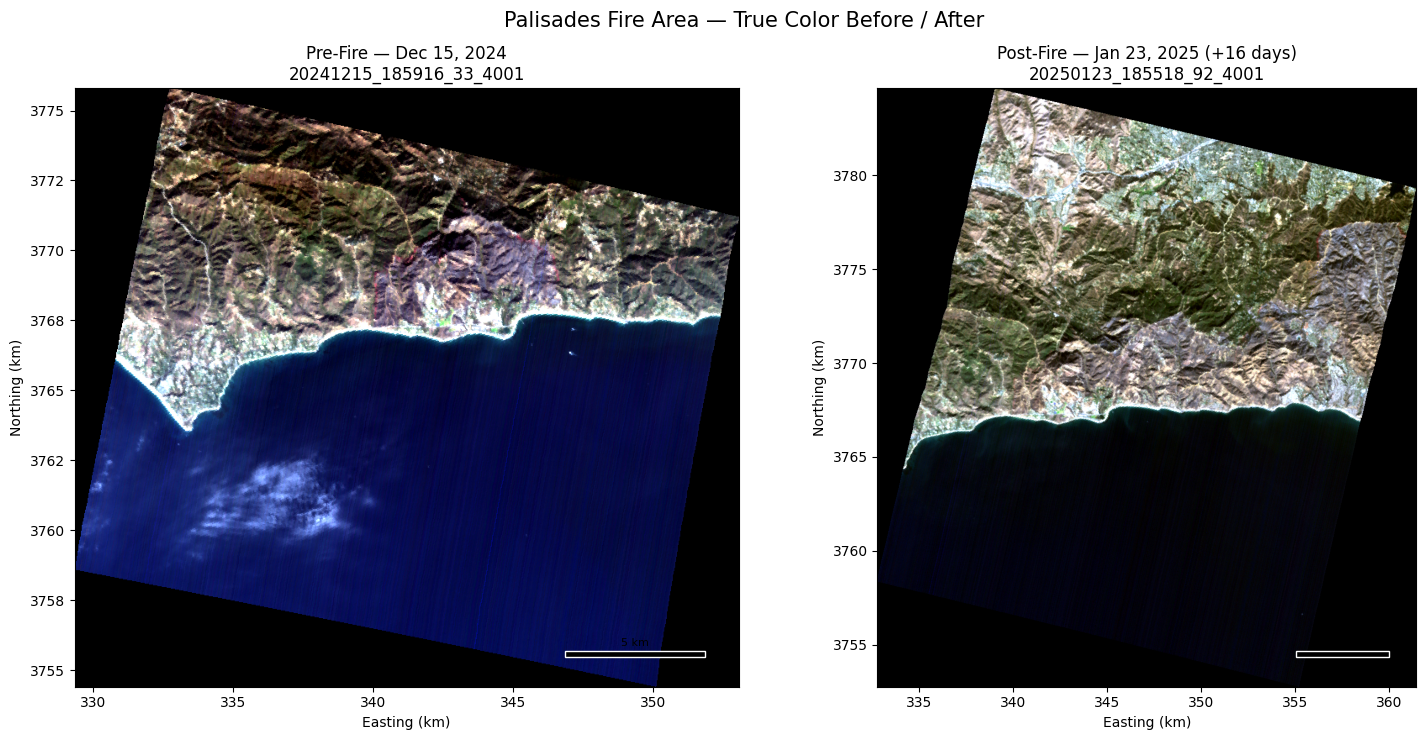

In [5]:
PRE_FIRE_SCENE = "20241215_185916_33_4001"
POST_FIRE_SCENE = "20250123_185518_92_4001"  # swath overlapping the pre-fire footprint

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))

for ax, scene_id, label in (
    (axes[0], PRE_FIRE_SCENE, "Pre-Fire — Dec 15, 2024"),
    (axes[1], POST_FIRE_SCENE, "Post-Fire — Jan 23, 2025 (+16 days)"),
):
    try:
        ds = load_visible_nir(scene_id)
        rgb = true_color_array(ds)
        plot_true_color(ds, rgb, f"{label}\n{scene_id}", ax=ax)
    except FileNotFoundError as exc:
        ax.text(0.5, 0.5, str(exc), ha="center", va="center", wrap=True, transform=ax.transAxes)
        ax.set_title(label)

fig.suptitle("Palisades Fire Area — True Color Before / After", fontsize=15)
fig.tight_layout()
plt.show()

True color shows *that* the landscape burned; a spectral index quantifies it. As a preview
of the index-based products built out in Notebooks 02–04, here's `tanager.plot_map()` — the
library's single-band map renderer — applied to NDVI computed from the pre-fire scene. Every
product map from here through Notebook 05 (NBR, dNBR, CBI, LFMC, severity class) goes through
this same function with a different `product_name` key into `PRODUCT_STYLES`.

NDVI range: [-1.00, 1.00], mean 0.06


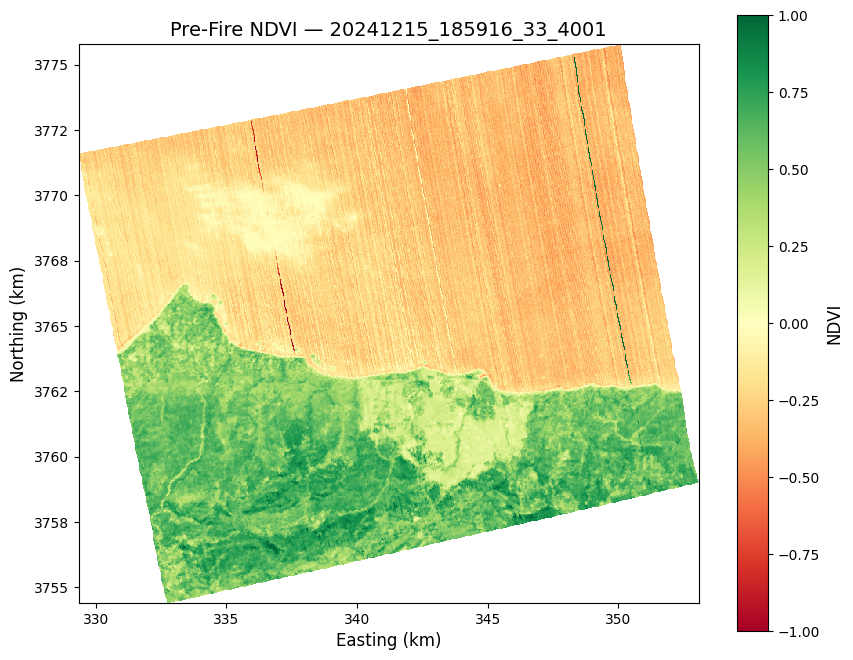

In [6]:
pre_fire_ds = load_visible_nir(PRE_FIRE_SCENE)
pre_fire_ndvi = ndvi(pre_fire_ds)

print(
    f"NDVI range: [{float(np.nanmin(pre_fire_ndvi)):.2f}, {float(np.nanmax(pre_fire_ndvi)):.2f}], "
    f"mean {float(np.nanmean(pre_fire_ndvi)):.2f}"
)

tanager.plot_map(
    pre_fire_ndvi,
    title=f"Pre-Fire NDVI — {PRE_FIRE_SCENE}",
    product_name="ndvi",
    basemap=False,
)
plt.show()

## 4. Spatial Context

Tanager-1's 18 km swath means no single scene covers the whole LA fire complex, and — as the
Jan 23 swath-1/swath-2 split showed above — successive overpasses can drift enough that a
"same day" pair doesn't actually overlap. Before committing to scene pairings in later
notebooks, we plot every LA-area footprint together, colored by recovery phase, so the actual
spatial coverage (and its gaps) is visible up front.

We build this two ways: a static, always-available matplotlib overview (works with zero extra
dependencies or network access beyond the STAC query already made above), and an interactive
Leaflet map via `tanager.interactive_map()` for exploring footprints against satellite
imagery. The interactive map depends on `leafmap`/`folium` plus, in some environments, a
Jupyter widget backend — both wrapped in `try`/`except` so a missing dependency or a headless
kernel degrades gracefully instead of breaking the notebook.

8/8 scene footprint(s) available for mapping (live STAC bounding boxes).


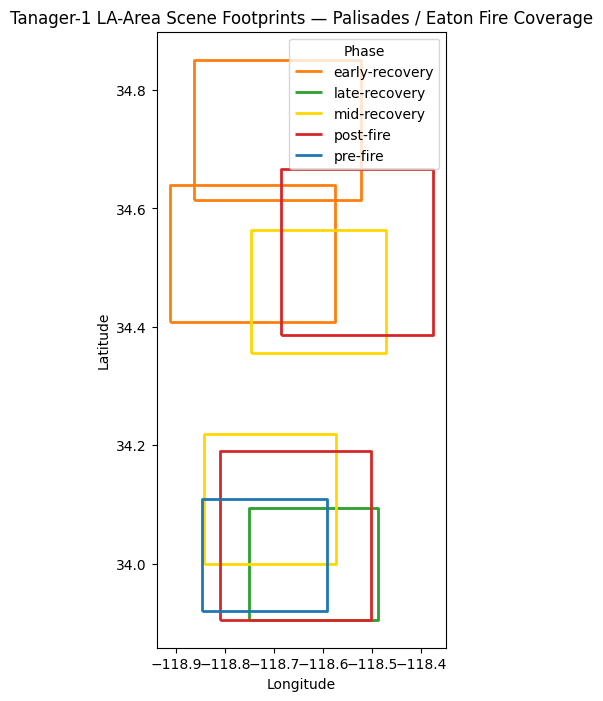

In [7]:
import geopandas as gpd
from shapely.geometry import box as shapely_box

PHASE_COLORS = {
    "pre-fire": "tab:blue",
    "post-fire": "tab:red",
    "early-recovery": "tab:orange",
    "mid-recovery": "gold",
    "late-recovery": "tab:green",
}

footprint_rows = [
    {"scene_id": row.scene_id, "phase": row.phase, "geometry": shapely_box(*row.bbox_wgs84)}
    for row in scene_table.itertuples()
    if row.bbox_wgs84 is not None
]
footprints = gpd.GeoDataFrame(footprint_rows, crs="EPSG:4326")

print(
    f"{len(footprints)}/{len(scene_table)} scene footprint(s) available for mapping "
    f"({'live STAC bounding boxes' if stac_available else 'STAC catalog unreachable — none cached'})."
)

fig, ax = plt.subplots(figsize=(9, 8))
if len(footprints) > 0:
    for phase, group in footprints.groupby("phase"):
        group.boundary.plot(ax=ax, color=PHASE_COLORS.get(phase, "gray"), linewidth=2, label=phase)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Tanager-1 LA-Area Scene Footprints — Palisades / Eaton Fire Coverage")
    ax.legend(title="Phase", loc="best")
    try:
        tanager.add_basemap(ax, source="terrain", crs="EPSG:4326", alpha=0.5)
    except Exception as exc:  # pragma: no cover - network-dependent
        print(f"Basemap tiles unavailable ({exc}); footprints shown without imagery context.")
else:
    ax.text(
        0.5, 0.5, "No footprint data available — STAC catalog was unreachable.",
        ha="center", va="center", transform=ax.transAxes,
    )
plt.show()

In [8]:
from IPython.display import display

try:
    if len(footprints) > 0:
        center = (float(footprints.geometry.centroid.y.mean()), float(footprints.geometry.centroid.x.mean()))
    else:
        center = (34.05, -118.6)  # Palisades/Eaton fire area fallback center

    interactive_footprint_map = tanager.interactive_map(
        layers=None,
        center=center,
        zoom=10,
        perimeters=footprints if len(footprints) > 0 else None,
        basemap="satellite",
    )
    # Explicit display() — a bare expression nested inside a try/except block does not
    # trigger IPython's displayhook (that only fires for a top-level expression statement),
    # so without this the widget would silently fail to render in a real notebook session.
    display(interactive_footprint_map)
except ImportError as exc:
    print(
        f"Interactive map unavailable: {exc}\n"
        "Install one of the optional backends with: pip install leafmap  (or)  pip install folium"
    )
except Exception as exc:  # pragma: no cover - environment-dependent (no display/widget support)
    print(f"interactive_map() could not render in this environment: {exc}")

/tmp/ipykernel_1307305/1077118271.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = (float(footprints.geometry.centroid.y.mean()), float(footprints.geometry.centroid.x.mean()))


Map(center=[34.301884197754475, -118.66015519024822], controls=(ZoomControl(options=['position', 'zoom_in_text…

## 5. Summary

**What the data tells us:**

- Tanager-1's fire collection holds 11 scenes total; **8 fall inside the LA-area Palisades/
  Eaton footprint** and span pre-fire (Dec 15, 2024) through late-recovery (~256 days
  post-ignition, Sep 2025). The remaining 3 are unrelated Utah calibration passes.
- The true-color quicklooks make the burn scar immediately visible along the Palisades
  coastline between the Dec 15 and Jan 23 acquisitions — the qualitative signal MESMA and the
  spectral indices in Notebook 02 will quantify.
- Scene pairing is not automatic: the two Jan 23 swaths acquired eleven seconds apart cover
  different ground, and only one overlaps the pre-fire baseline. Every multi-date comparison
  in this project has to check spatial overlap explicitly rather than assuming same-day
  scenes line up — a pattern we carry into the dNBR and temporal-trajectory work in
  Notebooks 02 and 04.
- Only 4 of the 8 LA scenes are downloaded locally as of this notebook run (pre-fire, both
  Jan 23 swaths, and the first Apr 7 early-recovery swath). The remaining scenes would need
  `tanager.download_scene()` before they can feed later notebooks — a known constraint,
  not a bug: `ortho_sr` products run 800 MB–1.4 GB each.

**What we'll analyze next:**

- **Notebook 02 (Burn Severity)** — spectral unmixing (MESMA) on the pre-/post-fire pair
  identified here, producing char/vegetation/soil fraction maps and a Composite Burn Index.
- **Notebook 03 (Fuel Moisture)** — hyperspectral water-absorption indices and PLSR
  regression to estimate live fuel moisture content, a lead indicator of fire risk.
- **Notebook 04 (Temporal Recovery)** — trajectories across the recovery-phase scenes
  inventoried above, tracking vegetation regrowth from post-fire through late-recovery.
- **Notebook 05 (Sensor Comparison)** — quantifying what Tanager-1's 426 bands buy over
  EMIT, PRISMA, and Sentinel-2 for this same burn scar.

*During this notebook we also found and filed a verified visualization bug — `plot_map()`,
`plot_before_after()`, and `plot_severity_summary()` render real Tanager scenes north-south
flipped (a known orientation issue) — worked around here with a purpose-built, orientation-aware
renderer for the true-color composites above.*